# Wavelength-Dependent CalibrationOptimizes all 4 detector parameters (scatter_length, wall_reflection_rate,sensor_reflection_rate, absorption_length) at different laser wavelengths.The "true" values for scatter and absorption come from the water mediumphysics at each wavelength. This tests whether the optimizer can recoverall parameters simultaneously, and how identifiability varies with wavelength.

In [1]:
import sys
import os
while not os.path.isdir('config') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())

from lucid.geometry import generate_detector
from lucid.sources import laser_source
from lucid.losses import WC_smooth_loss
from lucid.simulation import setup_event_simulator
from lucid.detector_params import (
    DetectorParams,
    normalize_params, denormalize_params, default_bounds,
    make_optimization_mask,
)
from lucid.wavelength.medium import make_medium, load_qe_curve

import jax
import jax.numpy as jnp
from jax import value_and_grad, jit
import optax
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time

SK_QE_PATH = 'config/pmt/SK_QE.json'

# --- flat<->nested DetectorParams helpers (the params pytree is nested by sub-tuple) ---
from lucid.detector_params import _FIELD_TO_SUBTUPLE
def get_flat(dp, name):
    return getattr(getattr(dp, _FIELD_TO_SUBTUPLE[name]), name)
def set_flat(dp, **kw):
    for _n, _v in kw.items():
        _s = _FIELD_TO_SUBTUPLE[_n]
        dp = dp._replace(**{_s: getattr(dp, _s)._replace(**{_n: _v})})
    return dp

## Configuration

In [2]:
GEOM = 'config/SK_like_geom_config.json'
GRID_KW = dict(n_cap=80, n_angular=120, n_height=80)

detector = generate_detector(GEOM)
detector_points = jnp.array(detector.all_points)
NUM_SENSORS = len(detector_points)

# Wavelength grid for medium lookup
wl_grid = jnp.linspace(280, 650, 371)
medium = make_medium('water', wavelength_grid=wl_grid)
qe_fn = load_qe_curve(SK_QE_PATH)

# Wavelengths to test
WAVELENGTHS = [350, 375, 405, 450, 500]

# Optimizer settings
NPHOT = 300_000
K = 8          # sufficient for all wavelengths (estimated K_99% <= 6)
NPHOT_TRUE = 2_000_000
K_TRUE = 8
ADAM_LR = 0.05
ADAM_ITERS = 200
WARMUP_FRAC = 0.4
N_INIT_GUESSES = 1
INIT_FRAC_DIFF = 0.5
SOURCE_INTENSITY = 100_000_000

print(f'Detector: {NUM_SENSORS} sensors')
print(f'Optimizer: Nphot={NPHOT}, K={K}, {ADAM_ITERS} iters')

Detector: 10764 sensors
Optimizer: Nphot=300000, K=8, 200 iters


## True values from water medium at each wavelength

In [3]:
print(f'{"wl (nm)":>8s}  {"L_scat (m)":>10s}  {"L_abs (m)":>10s}  {"QE":>6s}')
print('-' * 40)
true_params_per_wl = {}
for wl in WAVELENGTHS:
    sc = float(jnp.interp(float(wl), wl_grid, medium.scatter_coeff))
    ac = float(jnp.interp(float(wl), wl_grid, medium.absorption_coeff))
    L_s, L_a = 1.0/sc, 1.0/ac
    qe_val = float(qe_fn(float(wl)))
    print(f'{wl:8d}  {L_s:10.1f}  {L_a:10.1f}  {qe_val:6.3f}')
    true_params_per_wl[wl] = {
        'scatter_length': L_s,
        'absorption_length': L_a,
        'wall_reflection_rate': 0.2,
        'sensor_reflection_rate': 0.2,
        'qe': qe_val,
    }


 wl (nm)  L_scat (m)   L_abs (m)      QE
----------------------------------------


     350        91.3       607.9   0.198
     375       128.3       551.6   0.223
     405       186.5       367.7   0.225
     450       308.3       145.7   0.191
     500       504.4        38.5   0.132


## Run calibration at each wavelengthFor each wavelength:1. Set true DetectorParams from medium physics2. Generate true data with those params3. Perturb initial guess4. Optimize all 4 parameters (scatter, absorption, wall_refl, sensor_refl)5. Track convergence

In [4]:
def run_calibration_at_wavelength(wl, true_dict, seed=42):
    """Run 4-param calibration at a specific wavelength."""
    true_dp = DetectorParams.from_flat(
        scatter_length=true_dict['scatter_length'],
        wall_reflection_rate=true_dict['wall_reflection_rate'],
        sensor_reflection_rate=true_dict['sensor_reflection_rate'],
        absorption_length=true_dict['absorption_length'],
        qe=true_dict['qe'],
        qe_corrections=jnp.ones(NUM_SENSORS))

    source = laser_source(
        position=[0.0, 0.0, detector.H / 2 - 0.1],
        intensity=SOURCE_INTENSITY)

    # Use wavelength_mode=False so we can optimize scatter/absorption as scalars
    sim_true = setup_event_simulator(
        GEOM, NPHOT_TRUE, temperature=None, K=K_TRUE,
        is_calibration=True, hit_mode='aggregated', default_detector_params=true_dp,
        wavelength_mode=False, **GRID_KW)
    sim_opt = setup_event_simulator(
        GEOM, NPHOT, temperature=None, K=K,
        is_calibration=True, hit_mode='aggregated', wavelength_mode=False, **GRID_KW)

    key = jax.random.PRNGKey(seed)
    ks, kd, ki = jax.random.split(key, 3)

    true_data = jax.lax.stop_gradient(sim_true(source, kd))
    print(f'  True data charge_sum={float(jnp.sum(true_data[0])):.0f}')

    # Perturbed initial guess
    mults = jax.random.uniform(ki, (4,), minval=1-INIT_FRAC_DIFF, maxval=1+INIT_FRAC_DIFF)
    init = DetectorParams.from_flat(
        scatter_length=jnp.clip(get_flat(true_dp, 'scatter_length') * mults[0],
                                5.0, max(get_flat(true_dp, 'scatter_length') * 2, 100.0)),
        wall_reflection_rate=jnp.clip(get_flat(true_dp, 'wall_reflection_rate') * mults[1], 0.05, 0.5),
        sensor_reflection_rate=jnp.clip(get_flat(true_dp, 'sensor_reflection_rate') * mults[2], 0.05, 0.4),
        absorption_length=jnp.clip(get_flat(true_dp, 'absorption_length') * mults[3],
                                   10.0, max(get_flat(true_dp, 'absorption_length') * 2, 500.0)),
        qe=get_flat(true_dp, 'qe'),
        qe_corrections=get_flat(true_dp, 'qe_corrections'))

    # Bounds wide enough for the true values at any wavelength
    bmin, bmax = default_bounds(NUM_SENSORS)
    bmin = set_flat(bmin, scatter_length=jnp.array(5.), wall_reflection_rate=jnp.array(0.05),
                         sensor_reflection_rate=jnp.array(0.05), absorption_length=jnp.array(10.))
    bmax = set_flat(bmax, scatter_length=jnp.array(max(get_flat(true_dp, 'scatter_length') * 3, 200.)),
                         absorption_length=jnp.array(max(get_flat(true_dp, 'absorption_length') * 3, 1000.)))

    TRAINABLE = {'scatter_length', 'wall_reflection_rate',
                 'sensor_reflection_rate', 'absorption_length'}

    @jit
    def step_fn(p):
        return value_and_grad(lambda p: WC_smooth_loss(
            detector_points, *true_data,
            *sim_opt(source, denormalize_params(p, bmin, bmax), ks),
            lambda_poisson=1.0, lambda_time=0.0, tau=2.0))(p)

    params = normalize_params(init, bmin, bmax)
    mask = make_optimization_mask(params, TRAINABLE)
    labels = jax.tree.map(lambda m: 'train' if m else 'freeze', mask)
    warmup_steps = int(WARMUP_FRAC * ADAM_ITERS)
    sched = optax.warmup_constant_schedule(init_value=0., peak_value=ADAM_LR,
                                           warmup_steps=warmup_steps)
    opt = optax.multi_transform({
        'train': optax.adam(learning_rate=sched, b1=0.95, b2=0.99),
        'freeze': optax.set_to_zero(),
    }, labels)
    opt_state = opt.init(params)

    # Warmup JIT
    _ = step_fn(params); jax.block_until_ready(_)

    losses = []
    param_history = []
    t0 = time.time()

    for i in tqdm(range(ADAM_ITERS), desc=f'{wl}nm', leave=False):
        loss, grads = step_fn(params)
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        params = jax.tree.map(lambda p: jnp.clip(p, 0.01, 0.99), params)

        dp = denormalize_params(params, bmin, bmax)
        losses.append(float(loss))
        param_history.append({
            'scatter_length': float(get_flat(dp, 'scatter_length')),
            'wall_reflection_rate': float(get_flat(dp, 'wall_reflection_rate')),
            'sensor_reflection_rate': float(get_flat(dp, 'sensor_reflection_rate')),
            'absorption_length': float(get_flat(dp, 'absorption_length')),
        })

    elapsed = time.time() - t0
    final = denormalize_params(params, bmin, bmax)

    return {
        'wavelength': wl,
        'true': true_dict,
        'init': {
            'scatter_length': float(get_flat(init, 'scatter_length')),
            'wall_reflection_rate': float(get_flat(init, 'wall_reflection_rate')),
            'sensor_reflection_rate': float(get_flat(init, 'sensor_reflection_rate')),
            'absorption_length': float(get_flat(init, 'absorption_length')),
        },
        'final': {
            'scatter_length': float(get_flat(final, 'scatter_length')),
            'wall_reflection_rate': float(get_flat(final, 'wall_reflection_rate')),
            'sensor_reflection_rate': float(get_flat(final, 'sensor_reflection_rate')),
            'absorption_length': float(get_flat(final, 'absorption_length')),
        },
        'losses': losses,
        'param_history': param_history,
        'runtime': elapsed,
    }

In [5]:
results = {}
for wl in WAVELENGTHS:
    print(f'\n--- {wl} nm ---')
    print(f'  True: scatter={true_params_per_wl[wl]["scatter_length"]:.1f}m, '
          f'absorption={true_params_per_wl[wl]["absorption_length"]:.1f}m')
    r = run_calibration_at_wavelength(wl, true_params_per_wl[wl])
    results[wl] = r
    f = r['final']
    t = r['true']
    print(f'  Final: scatter={f["scatter_length"]:.1f} (true={t["scatter_length"]:.1f})  '
          f'absorption={f["absorption_length"]:.1f} (true={t["absorption_length"]:.1f})')
    print(f'  Final: wall_refl={f["wall_reflection_rate"]:.3f} (true=0.200)  '
          f'sensor_refl={f["sensor_reflection_rate"]:.3f} (true=0.200)')
    print(f'  Time: {r["runtime"]:.1f}s')



--- 350 nm ---
  True: scatter=91.3m, absorption=607.9m


  True data charge_sum=8739323


350nm:   0%|          | 0/200 [00:00<?, ?it/s]

350nm:   0%|          | 1/200 [00:01<06:34,  1.98s/it]

350nm:   1%|          | 2/200 [00:16<30:46,  9.32s/it]

...

500nm:  97%|█████████▋| 194/200 [00:30<00:00, 12.69it/s]

500nm:  98%|█████████▊| 196/200 [00:30<00:00, 12.48it/s]

500nm:  99%|█████████▉| 198/200 [00:30<00:00, 12.56it/s]

500nm: 100%|██████████| 200/200 [00:31<00:00, 12.58it/s]

  Final: scatter=1498.2 (true=504.4)  absorption=36.7 (true=38.5)
  Final: wall_refl=0.054 (true=0.200)  sensor_refl=0.054 (true=0.200)
  Time: 31.1s


## Summary table

In [6]:
print(f'{"wl":>5s}  {"scatter":>12s}  {"wall_refl":>12s}  {"sensor_refl":>12s}  {"absorption":>12s}  {"loss":>10s}')
print(f'{"":>5s}  {"true→final":>12s}  {"true→final":>12s}  {"true→final":>12s}  {"true→final":>12s}')
print('-' * 75)
for wl in WAVELENGTHS:
    r = results[wl]
    t, f = r['true'], r['final']
    print(f'{wl:5d}  '
          f'{t["scatter_length"]:5.0f}→{f["scatter_length"]:5.1f}  '
          f'{t["wall_reflection_rate"]:5.3f}→{f["wall_reflection_rate"]:.3f}  '
          f'{t["sensor_reflection_rate"]:5.3f}→{f["sensor_reflection_rate"]:.3f}  '
          f'{t["absorption_length"]:5.0f}→{f["absorption_length"]:5.1f}  '
          f'{r["losses"][-1]:10.6f}')

# Relative errors
print(f'\nRelative errors:')
print(f'{"wl":>5s}  {"scatter":>8s}  {"wall":>8s}  {"sensor":>8s}  {"absorp":>8s}')
print('-' * 45)
for wl in WAVELENGTHS:
    r = results[wl]
    t, f = r['true'], r['final']
    es = abs(f['scatter_length'] - t['scatter_length']) / t['scatter_length']
    ew = abs(f['wall_reflection_rate'] - t['wall_reflection_rate']) / t['wall_reflection_rate']
    er = abs(f['sensor_reflection_rate'] - t['sensor_reflection_rate']) / t['sensor_reflection_rate']
    ea = abs(f['absorption_length'] - t['absorption_length']) / t['absorption_length']
    print(f'{wl:5d}  {es:8.3f}  {ew:8.3f}  {er:8.3f}  {ea:8.3f}')


   wl       scatter     wall_refl   sensor_refl    absorption        loss
         true→final    true→final    true→final    true→final
---------------------------------------------------------------------------
  350     91→271.3  0.200→0.102  0.200→0.160    608→1752.7    0.006164
  375    128→381.2  0.200→0.058  0.200→0.112    552→1638.4    0.009895
  405    187→554.0  0.200→0.054  0.200→0.054    368→772.4    0.018541
  450    308→915.7  0.200→0.054  0.200→0.054    146→155.4    0.043236
  500    504→1498.2  0.200→0.054  0.200→0.054     38→ 36.7    0.132649

Relative errors:
   wl   scatter      wall    sensor    absorp
---------------------------------------------
  350     1.971     0.492     0.199     1.883
  375     1.970     0.710     0.441     1.970
  405     1.970     0.728     0.732     1.101
  450     1.970     0.728     0.732     0.066
  500     1.970     0.728     0.732     0.046


## Parameter convergence plots

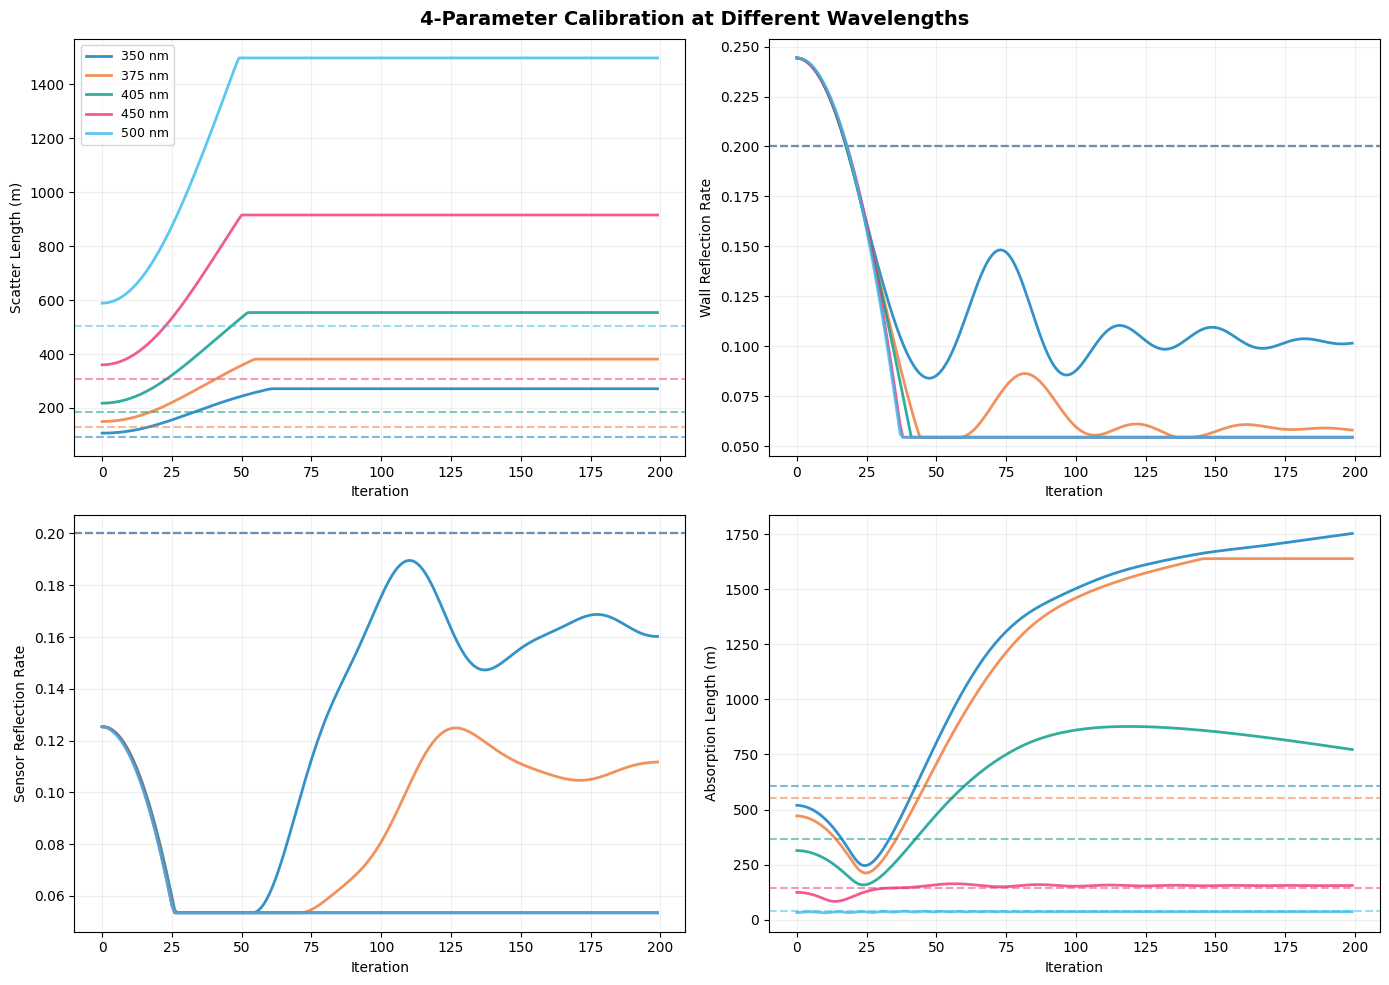

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
param_names = ['scatter_length', 'wall_reflection_rate', 'sensor_reflection_rate', 'absorption_length']
param_labels = ['Scatter Length (m)', 'Wall Reflection Rate', 'Sensor Reflection Rate', 'Absorption Length (m)']
colors = ['#0077BB', '#EE7733', '#009988', '#EE3377', '#33BBEE']

for pidx, (pname, plabel) in enumerate(zip(param_names, param_labels)):
    ax = axes[pidx // 2, pidx % 2]
    for widx, wl in enumerate(WAVELENGTHS):
        r = results[wl]
        vals = [h[pname] for h in r['param_history']]
        ax.plot(vals, color=colors[widx], linewidth=2, alpha=0.8, label=f'{wl} nm')
        ax.axhline(y=r['true'][pname], color=colors[widx], linestyle='--',
                   linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(plabel)
    ax.grid(True, alpha=0.2)
    if pidx == 0:
        ax.legend(loc='best', fontsize=9)

plt.suptitle('4-Parameter Calibration at Different Wavelengths', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()


## Loss curves

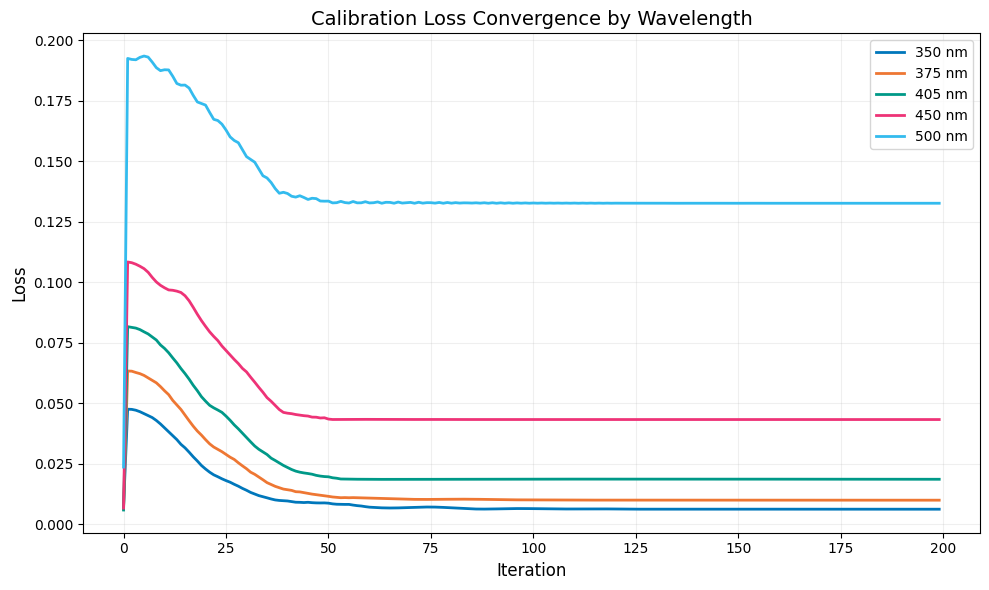

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for widx, wl in enumerate(WAVELENGTHS):
    r = results[wl]
    ax.plot(r['losses'], color=colors[widx], linewidth=2, label=f'{wl} nm')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Calibration Loss Convergence by Wavelength', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()


## Result — wavelength identifiability + single-source degeneracy

Two things to read off:

- **`scatter_length` is degenerate for a single source** and rails to its upper bound (~3× truth)
  at every wavelength — one downward laser fixes the *total* attenuation but not the
  scatter↔absorption split (same effect as `grad_param_calibration_multi_init_no_qe`). Recovering
  scatter needs **source diversity** (cf. `calibrate_optics.ipynb`).
- **Absorption identifiability improves with wavelength** — the `absorption_length` relative error
  falls from ~1.9 at 350 nm to ~0.05 at 500 nm. At long wavelengths absorption dominates the
  attenuation and is well determined; at short wavelengths scattering dominates and absorption is
  poorly separated. That wavelength dependence is the intended finding of this notebook.